# Part 1 - Analysis

## Import Libraries

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pl.Config.restore_defaults()

polars.config.Config

In [3]:
# Set the streaming engine as the default for all future operations
pl.Config.set_engine_affinity("streaming")
# Show all rows
pl.Config.set_tbl_rows(-1)

polars.config.Config

## Load Data

In [4]:
transaction_data = pl.scan_parquet(
    "../data/filtered_cleaned_transactions.parquet"
)

In [5]:
transaction_data.head(5).collect()

Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Transfer Type
datetime[μs],i64,str,i64,str,f64,str,f64,str,str,i64,str
2022-08-01 00:15:00,20,"""800104D70""",20,"""800104D70""",8095.07,"""US Dollar""",8095.07,"""US Dollar""","""Reinvestment""",0,"""Self-Transfer"""
2022-08-01 00:18:00,3196,"""800107150""",3196,"""800107150""",7739.29,"""US Dollar""",7739.29,"""US Dollar""","""Reinvestment""",0,"""Self-Transfer"""
2022-08-01 00:23:00,1208,"""80010E430""",1208,"""80010E430""",2654.22,"""US Dollar""",2654.22,"""US Dollar""","""Reinvestment""",0,"""Self-Transfer"""
2022-08-01 00:19:00,3203,"""80010EA80""",3203,"""80010EA80""",13284.41,"""US Dollar""",13284.41,"""US Dollar""","""Reinvestment""",0,"""Self-Transfer"""
2022-08-01 00:27:00,20,"""800104D20""",20,"""800104D20""",9.72,"""US Dollar""",9.72,"""US Dollar""","""Reinvestment""",0,"""Self-Transfer"""


## EDA 1 - Dataset Overview

In [6]:
# Get columns
transaction_data.collect_schema()

Schema([('Timestamp', Datetime(time_unit='us', time_zone=None)),
        ('From Bank', Int64),
        ('From Account', String),
        ('To Bank', Int64),
        ('To Account', String),
        ('Amount Received', Float64),
        ('Receiving Currency', String),
        ('Amount Paid', Float64),
        ('Payment Currency', String),
        ('Payment Format', String),
        ('Is Laundering', Int64),
        ('Transfer Type', String)])

In [7]:
# Get number of rows
transaction_data.select(
    pl.len().alias("Number of Transactions")
).collect()

Number of Transactions
u32
176060109


In [8]:
# Get number of unique sender and receiver banks and accounts
transaction_data.select(
    pl.col("From Bank").n_unique().alias("Unique From Banks"),
    pl.col("To Bank").n_unique().alias("Unique To Banks"),
    pl.col("From Account").n_unique().alias("Unique From Accounts"),
    pl.col("To Account").n_unique().alias("Unique To Accounts"),
).collect()

Unique From Banks,Unique To Banks,Unique From Accounts,Unique To Accounts
u32,u32,u32,u32
119618,61525,2023404,1678924


In [9]:
# Get number of unique currencies and formats
transaction_data.select(
    pl.col("Receiving Currency").n_unique().alias("Receiving Currencies"),
    pl.col("Payment Currency").n_unique().alias("Payment Currencies"),
    pl.col("Payment Format").n_unique().alias("Payment Formats")
).collect()

Receiving Currencies,Payment Currencies,Payment Formats
u32,u32,u32
15,15,7


In [10]:
# Get class distribution
transaction_data.group_by("Is Laundering").agg(pl.len().alias("Count")).with_columns(
    (
        pl.col("Count") /
        pl.col("Count").sum() * 100
    )
    .alias("Percentage")).sort("Is Laundering").collect()

Is Laundering,Count,Percentage
i64,u32,f64
0,175963171,99.94494
1,96938,0.05506


In [11]:
daily_transactions = (
    transaction_data
    .group_by(
        pl.col("Timestamp").dt.date().alias("Date")
    )
    .agg(
        pl.len().alias("Transactions")
    )
    .sort("Date")
    .collect()
)

daily_transactions

Date,Transactions
date,u32
2022-08-01,4377577
2022-08-02,1894426
2022-08-03,1891654
2022-08-04,1890984
2022-08-05,2957127
2022-08-06,813053
2022-08-07,814101
2022-08-08,1891589
2022-08-09,1890246


## EDA 2: Transaction Amounts

### 2.1 Amount Paid and Received

In [12]:
amount_stats = transaction_data.select([
    pl.col("Amount Paid").count().alias("paid_count"),
    pl.col("Amount Paid").mean().alias("paid_mean"),
    pl.col("Amount Paid").median().alias("paid_median"),
    pl.col("Amount Paid").std().alias("paid_std"),
    pl.col("Amount Paid").min().alias("paid_min"),
    pl.col("Amount Paid").quantile(0.01).alias("paid_p01"),
    pl.col("Amount Paid").quantile(0.05).alias("paid_p05"),
    pl.col("Amount Paid").quantile(0.25).alias("paid_p25"),
    pl.col("Amount Paid").quantile(0.50).alias("paid_p50"),
    pl.col("Amount Paid").quantile(0.75).alias("paid_p75"),
    pl.col("Amount Paid").quantile(0.95).alias("paid_p95"),
    pl.col("Amount Paid").quantile(0.99).alias("paid_p99"),
    pl.col("Amount Paid").quantile(0.999).alias("paid_p999"),
    pl.col("Amount Paid").max().alias("paid_max"),

    pl.col("Amount Received").count().alias("received_count"),
    pl.col("Amount Received").mean().alias("received_mean"),
    pl.col("Amount Received").median().alias("received_median"),
    pl.col("Amount Received").std().alias("received_std"),
    pl.col("Amount Received").min().alias("received_min"),
    pl.col("Amount Received").quantile(0.01).alias("received_p01"),
    pl.col("Amount Received").quantile(0.05).alias("received_p05"),
    pl.col("Amount Received").quantile(0.25).alias("received_p25"),
    pl.col("Amount Received").quantile(0.50).alias("received_p50"),
    pl.col("Amount Received").quantile(0.75).alias("received_p75"),
    pl.col("Amount Received").quantile(0.95).alias("received_p95"),
    pl.col("Amount Received").quantile(0.99).alias("received_p99"),
    pl.col("Amount Received").quantile(0.999).alias("received_p999"),
    pl.col("Amount Received").max().alias("received_max"),
]).collect()

amount_stats

paid_count,paid_mean,paid_median,paid_std,paid_min,paid_p01,paid_p05,paid_p25,paid_p50,paid_p75,paid_p95,paid_p99,paid_p999,paid_max,received_count,received_mean,received_median,received_std,received_min,received_p01,received_p05,received_p25,received_p50,received_p75,received_p95,received_p99,received_p999,received_max
u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
176060109,4.8849e6,1380.95,1.2896e9,0.000001,0.045269,11.02,202.73,1380.95,10958.38,507442.67,1.0553e7,2.9525e8,4.8346e12,176060109,7.2646e6,1377.95,1.7056e9,0.000001,0.042008,10.85,201.39,1377.95,11023.17,530662.76,1.1674e7,3.4394e8,4.8346e12


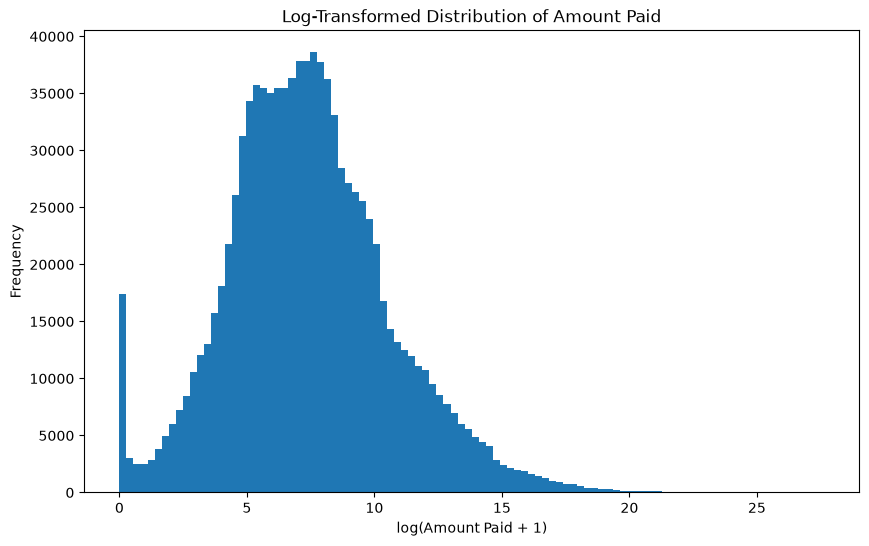

In [13]:
paid_sample = (
    transaction_data
    .select("Amount Paid")
    .collect(engine="streaming")
    .sample(n=1_000_000, seed=42)
)

paid_log = np.log1p(paid_sample["Amount Paid"].to_numpy())

plt.figure(figsize=(10, 6))

plt.hist(
    paid_log,
    bins=100
)

plt.xlabel("log(Amount Paid + 1)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Distribution of Amount Paid")

plt.show()

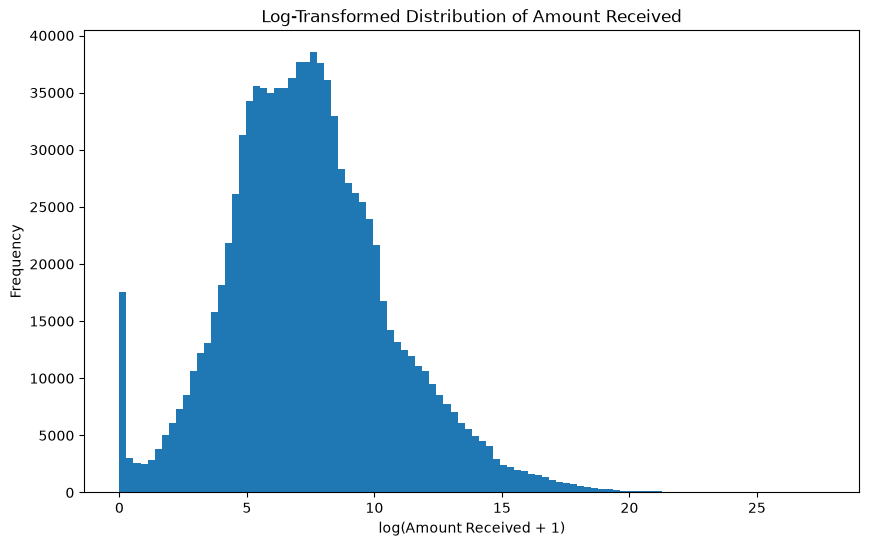

In [14]:
received_sample = (
    transaction_data
    .select("Amount Received")
    .collect(engine="streaming")
    .sample(n=1_000_000, seed=42)
)

received_log = np.log1p(received_sample["Amount Received"].to_numpy())

plt.figure(figsize=(10, 6))

plt.hist(
    received_log,
    bins=100
)

plt.xlabel("log(Amount Received + 1)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Distribution of Amount Received")

plt.show()

In [15]:
# Investigate spike at zero

zero_amounts = transaction_data.select([
    (pl.col("Amount Paid") == 0).sum().alias("zero_paid"),
    (pl.col("Amount Received") == 0).sum().alias("zero_received"),
    pl.col("Amount Paid").is_null().sum().alias("null_paid"),
    pl.col("Amount Received").is_null().sum().alias("null_received"),
]).collect()

zero_amounts

zero_paid,zero_received,null_paid,null_received
u32,u32,u32,u32
0,0,0,0


In [16]:
small_amount_stats = transaction_data.select([
    (pl.col("Amount Paid") < 0.01).sum().alias("paid_lt_0.01"),
    (pl.col("Amount Paid") < 1).sum().alias("paid_lt_1"),
    (pl.col("Amount Paid") < 10).sum().alias("paid_lt_10"),

    (pl.col("Amount Received") < 0.01).sum().alias("received_lt_0.01"),
    (pl.col("Amount Received") < 1).sum().alias("received_lt_1"),
    (pl.col("Amount Received") < 10).sum().alias("received_lt_10"),
]).collect()

small_amount_stats

paid_lt_0.01,paid_lt_1,paid_lt_10,received_lt_0.01,received_lt_1,received_lt_10
u32,u32,u32,u32,u32,u32
785077,3818980,8387167,836903,3842201,8455353


### 2.2 Paid vs Received Relationship

In [17]:
# Check how correlated the paid and received amounts are

amount_correlation = (
    transaction_data
    .select(
        pl.corr("Amount Paid", "Amount Received")
        .alias("paid_received_correlation")
    )
    .collect()
)

amount_correlation

paid_received_correlation
f64
0.761582


In [18]:
# Based on the correlation, check how many paid and received amounts are basically the same

amount_relationship = (
    transaction_data
    .select([
        (pl.col("Amount Paid") == pl.col("Amount Received"))
        .sum()
        .alias("exactly_equal"),

        (
            (pl.col("Amount Paid") - pl.col("Amount Received"))
            .abs() < 0.01
        )
        .sum()
        .alias("within_0.01"),

        (
            (pl.col("Amount Paid") - pl.col("Amount Received"))
            .abs() < 1
        )
        .sum()
        .alias("within_1"),
    ])
    .collect()
)

amount_relationship

exactly_equal,within_0.01,within_1
u32,u32,u32
173365830,173373186,173441468


In [19]:
# Investigate same currency and cross_currency

currency_relationship = (
    transaction_data
    .with_columns(
        (pl.col("Payment Currency") == pl.col("Receiving Currency"))
        .alias("same_currency")
    )
    .group_by("same_currency")
    .agg([
        pl.len().alias("transactions"),

        (
            pl.col("Amount Paid") == pl.col("Amount Received")
        ).sum().alias("exactly_equal"),

        (
            (pl.col("Amount Paid") - pl.col("Amount Received")).abs()
        ).median().alias("median_absolute_difference"),

        (
            (pl.col("Amount Paid") - pl.col("Amount Received")).abs()
        ).mean().alias("mean_absolute_difference"),

        pl.corr(
            "Amount Paid",
            "Amount Received"
        ).alias("correlation")
    ])
    .collect()
)

currency_relationship

same_currency,transactions,exactly_equal,median_absolute_difference,mean_absolute_difference,correlation
bool,u32,u32,f64,f64,f64
false,2694659,380,576.88,1.5630e8,0.330972
true,173365450,173365450,0.0,0.0,1.0


### 2.3 Extreme Values

In [20]:
extreme_paid = (
    transaction_data
    .select([
        "Timestamp",
        "From Bank",
        "From Account",
        "To Bank",
        "To Account",
        "Amount Paid",
        "Payment Currency",
        "Amount Received",
        "Receiving Currency",
        "Payment Format",
        "Is Laundering"
    ])
    .sort("Amount Paid", descending=True)
    .head(5)
    .collect()
)

extreme_paid

Timestamp,From Bank,From Account,To Bank,To Account,Amount Paid,Payment Currency,Amount Received,Receiving Currency,Payment Format,Is Laundering
datetime[μs],i64,str,i64,str,f64,str,f64,str,str,i64
2022-09-25 09:03:00,44763,"""810E31F70""",245868,"""810E53290""",4.8346e12,"""Yen""",4.8346e12,"""Yen""","""ACH""",0
2022-08-25 06:37:00,240864,"""810C6DCE0""",243641,"""810C73E00""",3.2149e12,"""Yen""",3.2149e12,"""Yen""","""ACH""",0
2022-11-03 12:15:00,74940,"""81CB661F0""",77357,"""81C128390""",2.3655e12,"""Ruble""",2.3655e12,"""Ruble""","""ACH""",0
2022-10-30 12:25:00,8640,"""805F83E00""",74695,"""820201D40""",2.0206e12,"""Ruble""",2.0206e12,"""Ruble""","""Cash""",0
2022-08-01 10:17:00,8640,"""805F83E00""",74695,"""820201D40""",2.0206e12,"""Ruble""",2.0206e12,"""Ruble""","""Cash""",0


In [21]:
extreme_received = (
    transaction_data
    .select([
        "Timestamp",
        "From Bank",
        "From Account",
        "To Bank",
        "To Account",
        "Amount Paid",
        "Payment Currency",
        "Amount Received",
        "Receiving Currency",
        "Payment Format",
        "Is Laundering"
    ])
    .sort("Amount Received", descending=True)
    .head(5)
    .collect()
)

extreme_received

Timestamp,From Bank,From Account,To Bank,To Account,Amount Paid,Payment Currency,Amount Received,Receiving Currency,Payment Format,Is Laundering
datetime[μs],i64,str,i64,str,f64,str,f64,str,str,i64
2022-09-25 09:03:00,44763,"""810E31F70""",245868,"""810E53290""",4.8346e12,"""Yen""",4.8346e12,"""Yen""","""ACH""",0
2022-08-25 06:37:00,240864,"""810C6DCE0""",243641,"""810C73E00""",3.2149e12,"""Yen""",3.2149e12,"""Yen""","""ACH""",0
2022-11-03 12:15:00,74940,"""81CB661F0""",77357,"""81C128390""",2.3655e12,"""Ruble""",2.3655e12,"""Ruble""","""ACH""",0
2022-10-30 12:25:00,8640,"""805F83E00""",8640,"""805F83E00""",2.5971e10,"""US Dollar""",2.0206e12,"""Ruble""","""ACH""",0
2022-09-30 00:08:00,8640,"""805F83E00""",74695,"""820201D40""",2.0206e12,"""Ruble""",2.0206e12,"""Ruble""","""Cash""",0


## EDA 3 - Temporal Behaviour

### 3.1 Visualise daily transactions

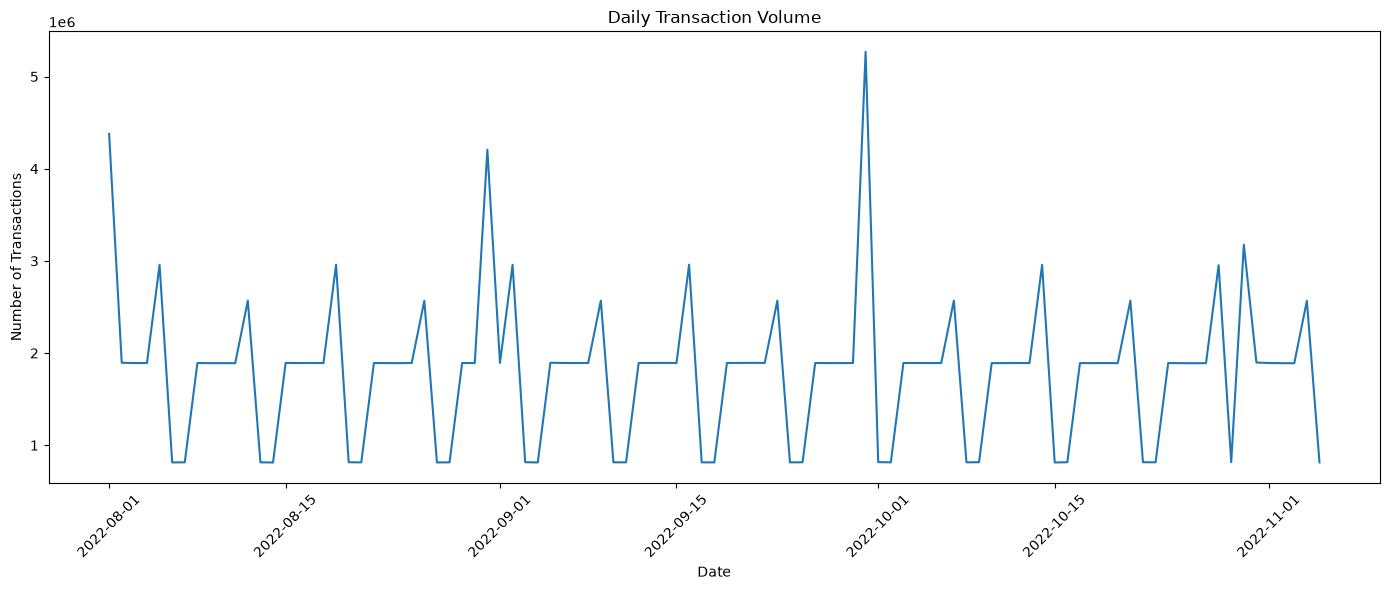

In [22]:
# Use daily_transactions from EDA 1 

plt.figure(figsize=(14, 6))

plt.plot(
    daily_transactions["Date"],
    daily_transactions["Transactions"]
)

plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.title("Daily Transaction Volume")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Transactions by hour

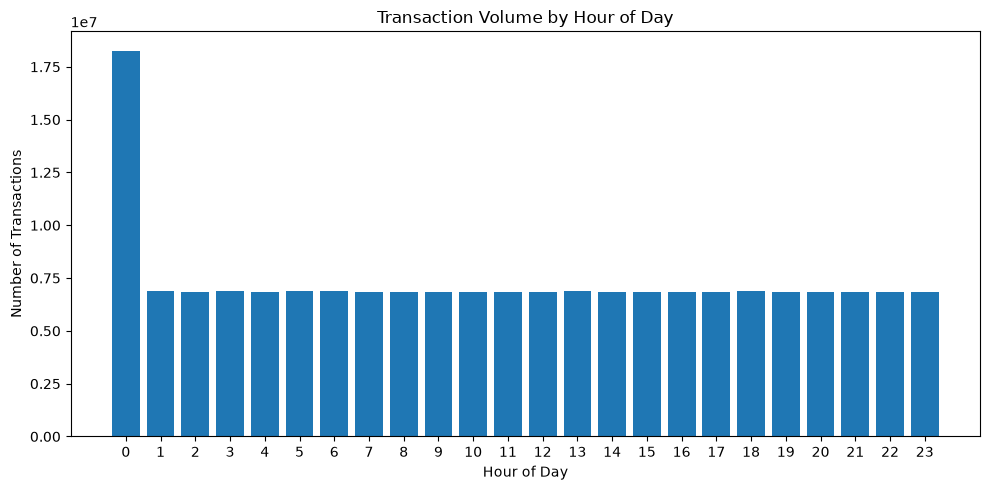

In [23]:
hourly_transactions = (
    transaction_data
    .group_by(
        pl.col("Timestamp").dt.hour().alias("Hour")
    )
    .agg(
        pl.len().alias("Transactions")
    )
    .sort("Hour")
    .collect()
)

plt.figure(figsize=(10, 5))

plt.bar(
    hourly_transactions["Hour"],
    hourly_transactions["Transactions"]
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.title("Transaction Volume by Hour of Day")

plt.xticks(range(24))
plt.tight_layout()
plt.show()

### 3.2 Laundering transactions over time

In [24]:
daily_laundering = (
    transaction_data
    .with_columns(
        pl.col("Timestamp").dt.date().alias("Date")
    )
    .group_by("Date")
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering")
    ])
    .with_columns(
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate")
    )
    .sort("Date")
    .collect()
)

daily_laundering

Date,Transactions,Laundering,Laundering Rate
date,u32,i64,f64
2022-08-01,4377577,871,0.019897
2022-08-02,1894426,794,0.041912
2022-08-03,1891654,760,0.040176
2022-08-04,1890984,821,0.043417
2022-08-05,2957127,936,0.031652
2022-08-06,813053,641,0.078839
2022-08-07,814101,581,0.071367
2022-08-08,1891589,828,0.043773
2022-08-09,1890246,798,0.042217


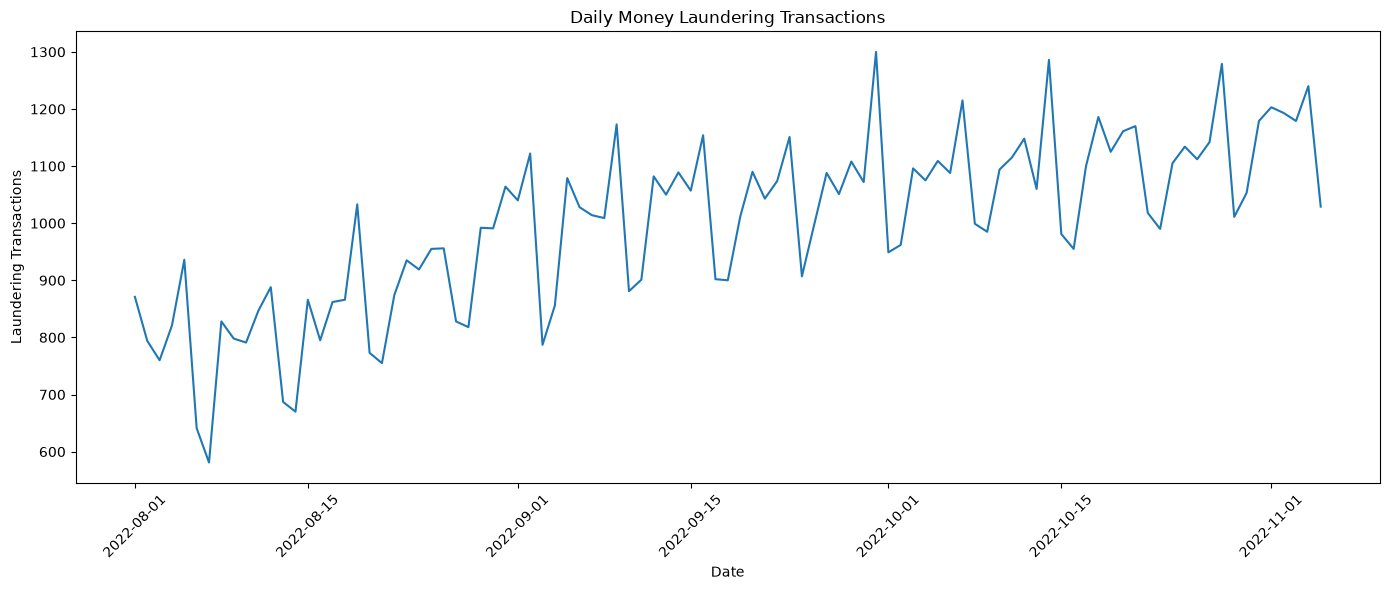

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_laundering["Date"],
    daily_laundering["Laundering"]
)

plt.xlabel("Date")
plt.ylabel("Laundering Transactions")
plt.title("Daily Money Laundering Transactions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

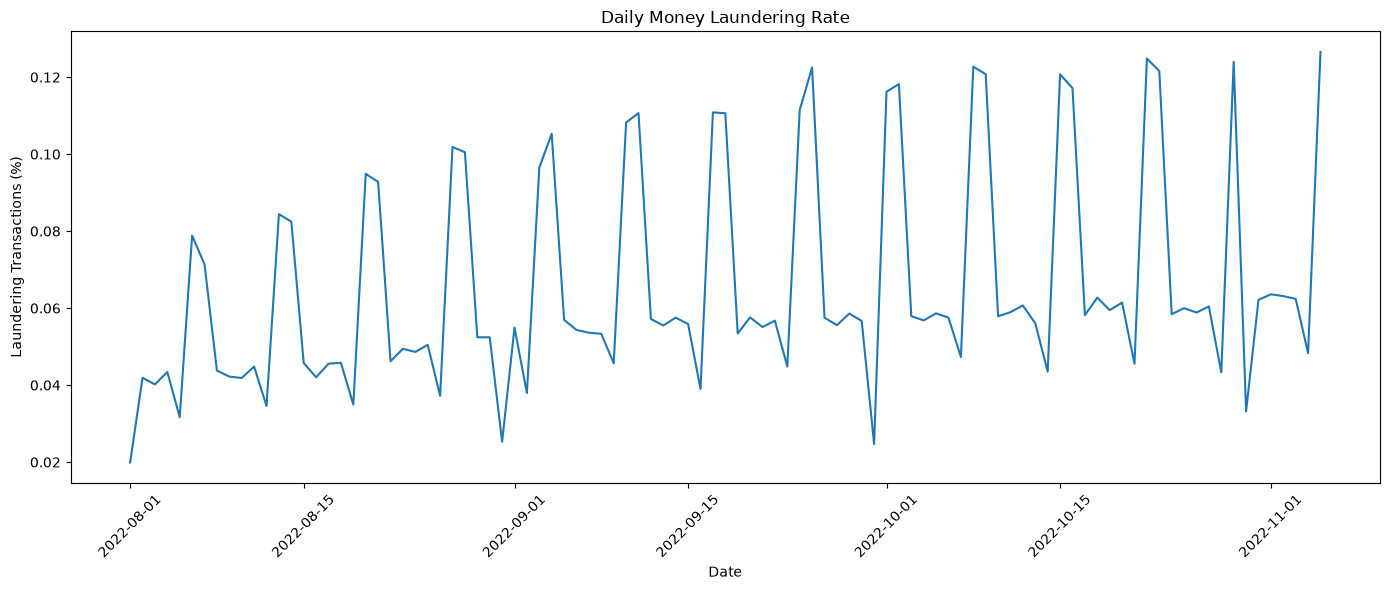

In [26]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_laundering["Date"],
    daily_laundering["Laundering Rate"]
)

plt.xlabel("Date")
plt.ylabel("Laundering Transactions (%)")
plt.title("Daily Money Laundering Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.3 Internal vs inter-bank transactions

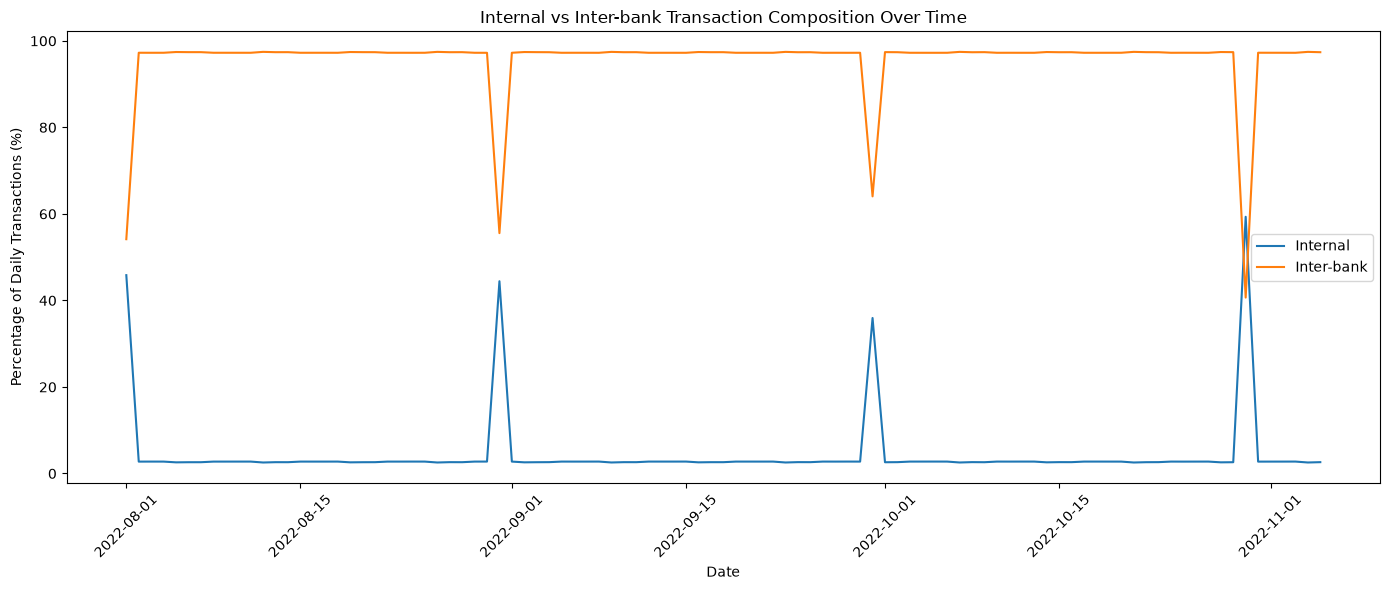

In [27]:
daily_transfer_type = (
    transaction_data
    .with_columns([
        pl.col("Timestamp").dt.date().alias("Date"),

        pl.when(
            pl.col("From Bank") == pl.col("To Bank")
        )
        .then(pl.lit("Internal"))
        .otherwise(pl.lit("Inter-bank"))
        .alias("Transfer Type")
    ])
    .group_by(["Date", "Transfer Type"])
    .agg(
        pl.len().alias("Transactions")
    )
    .with_columns(
        pl.col("Transactions")
        .sum()
        .over("Date")
        .alias("Daily Total")
    )
    .with_columns(
        (
            pl.col("Transactions") /
            pl.col("Daily Total") * 100
        ).alias("Percentage")
    )
    .sort(["Date", "Transfer Type"])
    .collect()
)

internal = daily_transfer_type.filter(
    pl.col("Transfer Type") == "Internal"
)

interbank = daily_transfer_type.filter(
    pl.col("Transfer Type") == "Inter-bank"
)

plt.figure(figsize=(14, 6))

plt.plot(
    internal["Date"],
    internal["Percentage"],
    label="Internal"
)

plt.plot(
    interbank["Date"],
    interbank["Percentage"],
    label="Inter-bank"
)

plt.xlabel("Date")
plt.ylabel("Percentage of Daily Transactions (%)")
plt.title("Internal vs Inter-bank Transaction Composition Over Time")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## EDA 4 - Transaction characteristics

In [28]:
# Get payment format distribution

payment_formats = (
    transaction_data
    .group_by("Payment Format")
    .agg(pl.len().alias("Transactions"))
    .with_columns(
        (pl.col("Transactions") / pl.col("Transactions").sum() * 100)
        .alias("Percentage")
    )
    .sort("Transactions", descending=True)
    .collect()
)

payment_formats

Payment Format,Transactions,Percentage
str,u32,f64
"""Cheque""",69361333,39.396393
"""Credit Card""",49911890,28.349346
"""ACH""",21561443,12.246637
"""Cash""",18040752,10.246928
"""Reinvestment""",7258238,4.122591
"""Wire""",6339912,3.600993
"""Bitcoin""",3586541,2.037112


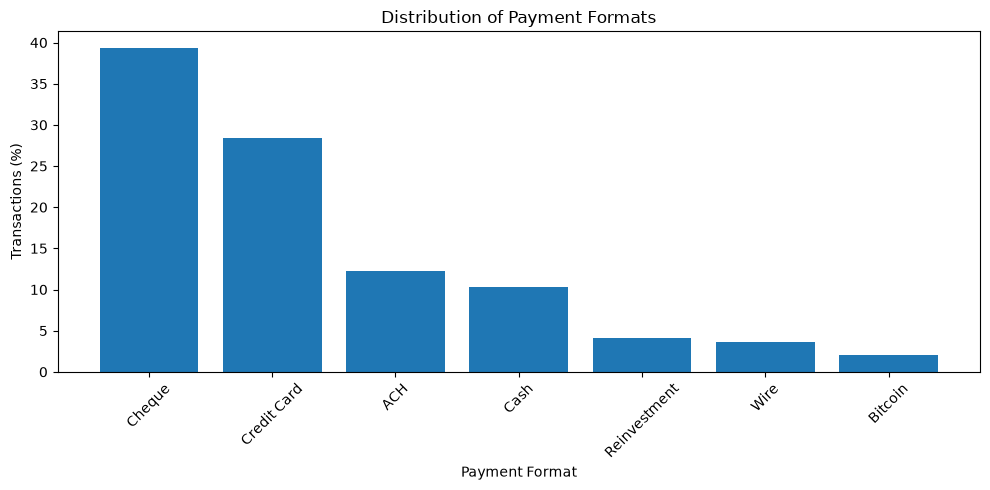

In [29]:
plt.figure(figsize=(10, 5))

plt.bar(
    payment_formats["Payment Format"],
    payment_formats["Percentage"]
)

plt.xlabel("Payment Format")
plt.ylabel("Transactions (%)")
plt.title("Distribution of Payment Formats")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Get payment and receiving currency distribution

payment_currencies = (
    transaction_data
    .group_by("Payment Currency")
    .agg(pl.len().alias("Transactions"))
    .with_columns(
        (pl.col("Transactions") / pl.col("Transactions").sum() * 100)
        .alias("Percentage")
    )
    .sort("Transactions", descending=True)
    .collect()
)

receiving_currencies = (
    transaction_data
    .group_by("Receiving Currency")
    .agg(pl.len().alias("Transactions"))
    .with_columns(
        (pl.col("Transactions") / pl.col("Transactions").sum() * 100)
        .alias("Percentage")
    )
    .sort("Transactions", descending=True)
    .collect()
)

currency_comparison = (
    payment_currencies
    .select([
        pl.col("Payment Currency").alias("Currency"),
        pl.col("Percentage").alias("Payment Percentage")
    ])
    .join(
        receiving_currencies.select([
            pl.col("Receiving Currency").alias("Currency"),
            pl.col("Percentage").alias("Receiving Percentage")
        ]),
        on="Currency"
    )
    .sort("Payment Percentage", descending=True)
)

currency_comparison

Currency,Payment Percentage,Receiving Percentage
str,f64,f64
"""US Dollar""",37.882953,37.602353
"""Euro""",23.569162,23.604704
"""Yuan""",5.42403,5.28
"""Rupee""",3.926794,3.9647
"""Canadian Dollar""",3.218709,3.256125
"""Swiss Franc""",3.149837,3.199158
"""Australian Dollar""",3.077443,3.122311
"""UK Pound""",3.042358,3.042143
"""Yen""",2.877877,2.896015


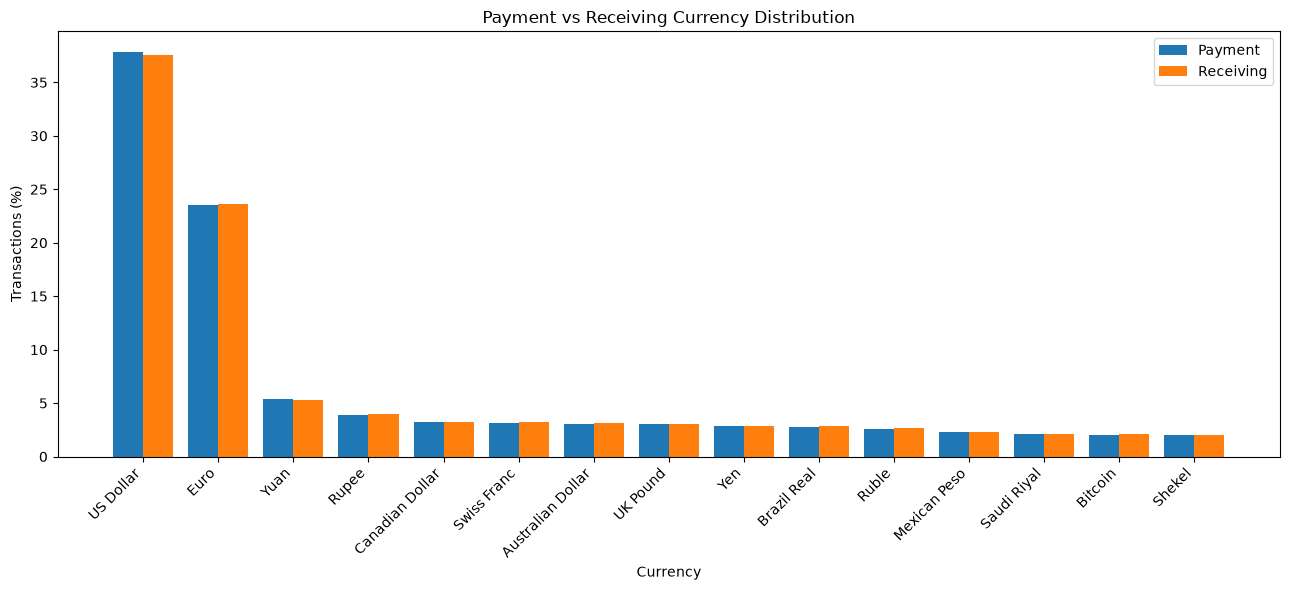

In [31]:
x = np.arange(currency_comparison.height)
width = 0.4

plt.figure(figsize=(13, 6))

plt.bar(
    x - width / 2,
    currency_comparison["Payment Percentage"],
    width,
    label="Payment"
)

plt.bar(
    x + width / 2,
    currency_comparison["Receiving Percentage"],
    width,
    label="Receiving"
)

plt.xticks(
    x,
    currency_comparison["Currency"],
    rotation=45,
    ha="right"
)

plt.xlabel("Currency")
plt.ylabel("Transactions (%)")
plt.title("Payment vs Receiving Currency Distribution")

plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# Get transfer type distribution

transfer_types = (
    transaction_data
    .with_columns(
        pl.when(pl.col("From Bank") == pl.col("To Bank"))
        .then(pl.lit("Internal"))
        .otherwise(pl.lit("Inter-bank"))
        .alias("Transfer Type")
    )
    .group_by("Transfer Type")
    .agg(pl.len().alias("Transactions"))
    .with_columns(
        (pl.col("Transactions") / pl.col("Transactions").sum() * 100)
        .alias("Percentage")
    )
    .sort("Transactions", descending=True)
    .collect()
)

transfer_types

Transfer Type,Transactions,Percentage
str,u32,f64
"""Inter-bank""",164127373,93.222351
"""Internal""",11932736,6.777649


In [33]:
# For cross-currency, what are the most popular currency conversions

currency_pairs = (
    transaction_data
    .filter(
        pl.col("Payment Currency") !=
        pl.col("Receiving Currency")
    )
    .group_by([
        "Payment Currency",
        "Receiving Currency"
    ])
    .agg(
        pl.len().alias("Transactions")
    )
    .sort("Transactions", descending=True)
    .head(15)
    .collect()
)

currency_pairs

Payment Currency,Receiving Currency,Transactions
str,str,u32
"""US Dollar""","""Euro""",584603
"""Euro""","""US Dollar""",473012
"""Yuan""","""US Dollar""",288166
"""US Dollar""","""Yuan""",129508
"""US Dollar""","""Rupee""",86184
"""US Dollar""","""Canadian Dollar""",74725
"""US Dollar""","""UK Pound""",67274
"""US Dollar""","""Swiss Franc""",67094
"""US Dollar""","""Australian Dollar""",63190


## EDA 5 - Money laundering patterns

### 5.1 Amount distributions by laundering status

In [34]:
# Get the ditributions of legitimate and laundered transactions

laundering_amount_stats = (
    transaction_data
    .group_by("Is Laundering")
    .agg([
        pl.len().alias("Transactions"),

        pl.col("Amount Paid").mean().alias("Paid Mean"),
        pl.col("Amount Paid").median().alias("Paid Median"),
        pl.col("Amount Paid").quantile(0.25).alias("Paid P25"),
        pl.col("Amount Paid").quantile(0.75).alias("Paid P75"),
        pl.col("Amount Paid").quantile(0.95).alias("Paid P95"),
        pl.col("Amount Paid").quantile(0.99).alias("Paid P99"),
        pl.col("Amount Paid").max().alias("Paid Max"),

        pl.col("Amount Received").mean().alias("Received Mean"),
        pl.col("Amount Received").median().alias("Received Median"),
        pl.col("Amount Received").quantile(0.25).alias("Received P25"),
        pl.col("Amount Received").quantile(0.75).alias("Received P75"),
        pl.col("Amount Received").quantile(0.95).alias("Received P95"),
        pl.col("Amount Received").quantile(0.99).alias("Received P99"),
        pl.col("Amount Received").max().alias("Received Max"),
    ])
    .sort("Is Laundering")
    .collect()
)

laundering_amount_stats

Is Laundering,Transactions,Paid Mean,Paid Median,Paid P25,Paid P75,Paid P95,Paid P99,Paid Max,Received Mean,Received Median,Received P25,Received P75,Received P95,Received P99,Received Max
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,175963171,4.8568e6,1379.61,202.58,10955.85,507473.15,1.0552e7,4.8346e12,7.2377e6,1376.62,201.24,11020.02,530779.12,1.1673e7,4.8346e12
1,96938,5.6028e7,3749.995,1318.36,14338.51,406488.8,1.4786e7,6.2154e11,5.6028e7,3749.995,1318.36,14338.51,406488.8,1.4786e7,6.2154e11


In [35]:
# Check same currency and cross currency for legitimate and laundered transactions

laundering_currency = (
    transaction_data
    .group_by("Is Laundering")
    .agg([
        pl.len().alias("Transactions"),

        (
            pl.col("Payment Currency") ==
            pl.col("Receiving Currency")
        )
        .sum()
        .alias("Same Currency"),

        (
            pl.col("Payment Currency") !=
            pl.col("Receiving Currency")
        )
        .sum()
        .alias("Cross Currency"),
    ])
    .with_columns([
        (
            pl.col("Same Currency") /
            pl.col("Transactions") * 100
        ).alias("Same Currency %"),

        (
            pl.col("Cross Currency") /
            pl.col("Transactions") * 100
        ).alias("Cross Currency %"),
    ])
    .sort("Is Laundering")
    .collect()
)

laundering_currency

Is Laundering,Transactions,Same Currency,Cross Currency,Same Currency %,Cross Currency %
i64,u32,u32,u32,f64,f64
0,175963171,173268512,2694659,98.468623,1.531377
1,96938,96938,0,100.0,0.0


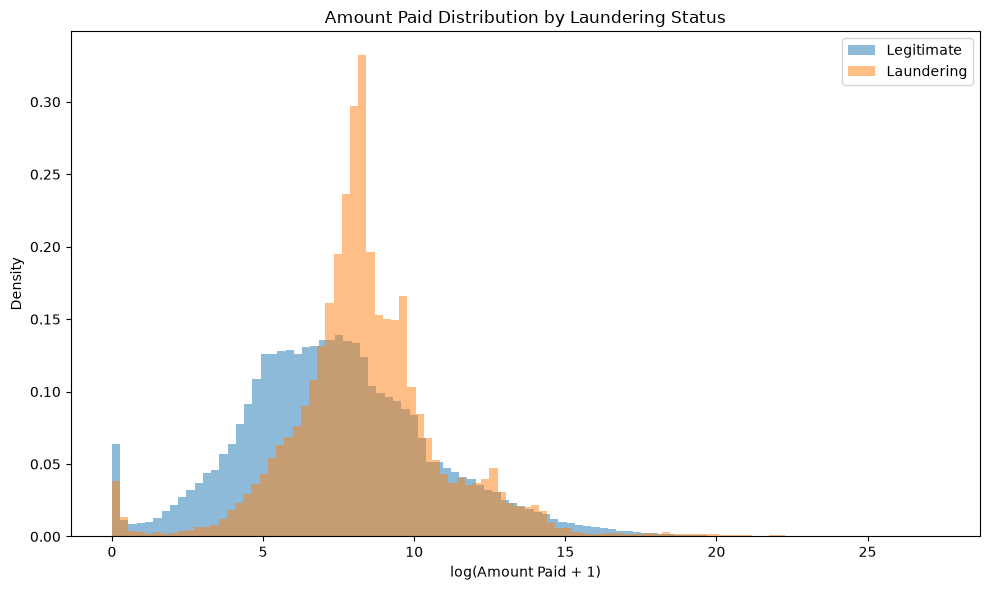

In [36]:
# Get all laundering transactions
laundering_amounts = (
    transaction_data
    .filter(pl.col("Is Laundering") == 1)
    .select("Amount Paid")
    .collect()
)

# Get a random selection of legitimate transactions
legitimate_amounts = (
    transaction_data
    .filter(pl.col("Is Laundering") == 0)
    .select("Amount Paid")
    .with_row_index("row_nr")
    .filter(pl.col("row_nr") % 1000 == 0)
    .select("Amount Paid")
    .collect()
)

laundering_log = np.log1p(
    laundering_amounts["Amount Paid"].to_numpy()
)

legitimate_log = np.log1p(
    legitimate_amounts["Amount Paid"].to_numpy()
)

plt.figure(figsize=(10, 6))

plt.hist(
    legitimate_log,
    bins=100,
    density=True,
    alpha=0.5,
    label="Legitimate"
)

plt.hist(
    laundering_log,
    bins=100,
    density=True,
    alpha=0.5,
    label="Laundering"
)

plt.xlabel("log(Amount Paid + 1)")
plt.ylabel("Density")
plt.title("Amount Paid Distribution by Laundering Status")
plt.legend()

plt.tight_layout()
plt.show()

### 5.2 Payment format vs laundering

In [37]:
format_laundering = (
    transaction_data
    .group_by("Payment Format")
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering")
    ])
    .with_columns([
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate"),

        (
            pl.col("Laundering") /
            pl.col("Laundering").sum() * 100
        ).alias("Share of Laundering")
    ])
    .sort("Laundering Rate", descending=True)
    .collect()
)

baseline_rate = 0.05506

format_laundering = format_laundering.with_columns(
    (
        pl.col("Laundering Rate") / baseline_rate
    ).alias("Relative Risk")
)

format_laundering

Payment Format,Transactions,Laundering,Laundering Rate,Share of Laundering,Relative Risk
str,u32,i64,f64,f64,f64
"""ACH""",21561443,71367,0.330994,73.621284,6.011508
"""Bitcoin""",3586541,1497,0.041739,1.544286,0.758071
"""Cash""",18040752,3514,0.019478,3.624997,0.353762
"""Cheque""",69361333,13003,0.018747,13.413728,0.340479
"""Credit Card""",49911890,7554,0.015135,7.79261,0.274876
"""Wire""",6339912,3,0.000047,0.003095,0.000859
"""Reinvestment""",7258238,0,0.0,0.0,0.0


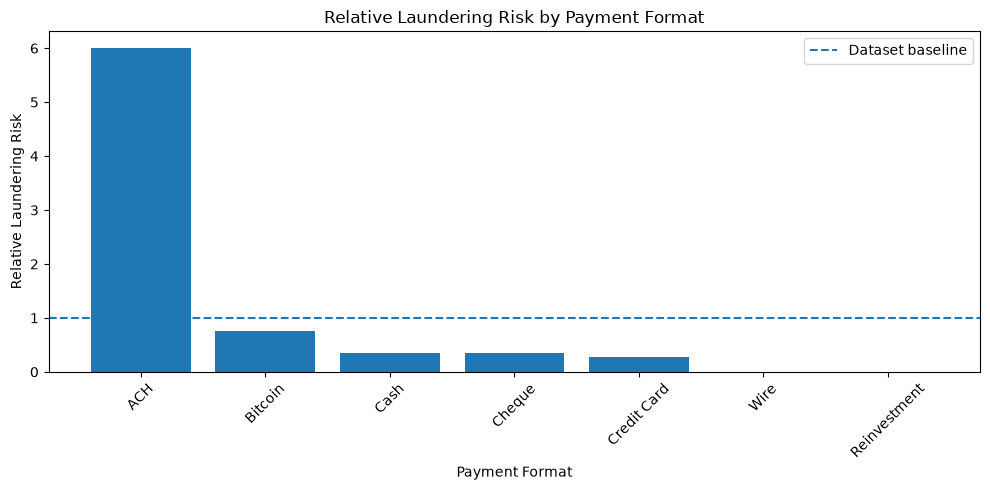

In [38]:
plt.figure(figsize=(10, 5))

plt.bar(
    format_laundering["Payment Format"],
    format_laundering["Relative Risk"]
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Dataset baseline"
)

plt.xlabel("Payment Format")
plt.ylabel("Relative Laundering Risk")
plt.title("Relative Laundering Risk by Payment Format")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 5.3 Transfer type vs laundering

In [39]:
transfer_laundering = (
    transaction_data
    .group_by("Transfer Type")
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering")
    ])
    .with_columns([
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate"),

        (
            pl.col("Laundering") /
            pl.col("Laundering").sum() * 100
        ).alias("Share of Laundering")
    ])
    .with_columns(
        (
            pl.col("Laundering Rate") / 0.064558
        ).alias("Relative Risk")
    )
    .sort("Laundering Rate", descending=True)
    .collect()
)

transfer_laundering

Transfer Type,Transactions,Laundering,Laundering Rate,Share of Laundering,Relative Risk
str,u32,i64,f64,f64,f64
"""Cross-Bank Transfer""",164127373,96190,0.058607,99.228373,0.907818
"""Standard Transfer""",1317582,713,0.054114,0.735522,0.838227
"""Self-Transfer""",10615154,35,0.00033,0.036106,0.005107


### 5.4 Currency vs laundering

In [40]:
currency_laundering = (
    transaction_data
    .group_by("Payment Currency")
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering")
    ])
    .with_columns([
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate"),

        (
            pl.col("Laundering") /
            pl.col("Laundering").sum() * 100
        ).alias("Share of Laundering")
    ])
    .with_columns(
        (
            pl.col("Laundering Rate") / 0.064558
        ).alias("Relative Risk")
    )
    .sort("Laundering Rate", descending=True)
    .collect()
)

currency_laundering

Payment Currency,Transactions,Laundering,Laundering Rate,Share of Laundering,Relative Risk
str,u32,i64,f64,f64,f64
"""Yen""",5066793,3136,0.061893,3.235057,0.958722
"""Ruble""",4580566,2801,0.06115,2.889476,0.947205
"""Euro""",41495892,24712,0.059553,25.492583,0.922471
"""Yuan""",9549554,5411,0.056662,5.581918,0.877697
"""US Dollar""",66696768,36968,0.055427,38.135716,0.858561
"""Canadian Dollar""",5666862,3083,0.054404,3.180383,0.842715
"""Rupee""",6913517,3726,0.053894,3.843694,0.834822
"""UK Pound""",5356378,2846,0.053133,2.935897,0.823026
"""Australian Dollar""",5418149,2743,0.050626,2.829644,0.784196


### 5.5 Bank-level laundering patterns

In [41]:
from_bank_laundering = (
    transaction_data
    .group_by("From Bank")
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering")
    ])
    .with_columns(
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate")
    )
    .collect()
)

In [42]:
bank_activity_stats = (
    from_bank_laundering
    .select([
        pl.col("Transactions").min().alias("Min"),
        pl.col("Transactions").quantile(0.25).alias("P25"),
        pl.col("Transactions").median().alias("Median"),
        pl.col("Transactions").quantile(0.75).alias("P75"),
        pl.col("Transactions").quantile(0.90).alias("P90"),
        pl.col("Transactions").quantile(0.95).alias("P95"),
        pl.col("Transactions").quantile(0.99).alias("P99"),
        pl.col("Transactions").max().alias("Max")
    ])
)

bank_activity_stats

Min,P25,Median,P75,P90,P95,P99,Max
u32,f64,f64,f64,f64,f64,f64,u32
1,6.0,18.0,70.0,168.0,411.0,35103.0,16716238


In [43]:
bank_laundering_counts = (
    from_bank_laundering
    .select([
        (pl.col("Laundering") == 0).sum().alias("Banks With No Laundering"),
        (pl.col("Laundering") > 0).sum().alias("Banks With Laundering"),
        (pl.col("Laundering") >= 5).sum().alias("Banks With 5+ Laundering"),
        (pl.col("Laundering") >= 10).sum().alias("Banks With 10+ Laundering"),
        (pl.col("Laundering") >= 50).sum().alias("Banks With 50+ Laundering")
    ])
)

bank_laundering_counts

Banks With No Laundering,Banks With Laundering,Banks With 5+ Laundering,Banks With 10+ Laundering,Banks With 50+ Laundering
u32,u32,u32,u32,u32
113846,5772,3688,2346,204


In [44]:
top_banks_laundering_count = (
    from_bank_laundering
    .with_columns(
        (
            pl.col("Laundering") / 96938 * 100
        ).alias("Share of Laundering")
    )
    .sort("Laundering", descending=True)
    .head(15)
)

top_banks_laundering_count

From Bank,Transactions,Laundering,Laundering Rate,Share of Laundering
i64,u32,i64,f64,f64
70,16716238,23647,0.141461,24.393943
11,983200,378,0.038446,0.38994
0,873192,301,0.034471,0.310508
12,885707,249,0.028113,0.256865
20,878243,245,0.027897,0.252739
3,539399,224,0.041528,0.231076
27,721684,183,0.025357,0.18878
14,543767,175,0.032183,0.180528
1226,332021,167,0.050298,0.172275


In [45]:
active_bank_laundering = (
    from_bank_laundering
    .filter(
        pl.col("Transactions") >= 22_672
    )
    .with_columns(
        (
            pl.col("Laundering Rate") / 0.064558
        ).alias("Relative Risk")
    )
    .sort("Laundering Rate", descending=True)
    .head(15)
)

active_bank_laundering

From Bank,Transactions,Laundering,Laundering Rate,Relative Risk
i64,u32,i64,f64,f64
235421,26558,41,0.154379,2.391324
176477,33315,50,0.150083,2.324771
129643,24292,36,0.148197,2.295563
57807,23268,34,0.146123,2.263444
70,16716238,23647,0.141461,2.191227
27992,23742,33,0.138994,2.153013
228375,22898,30,0.131016,2.029428
136607,34100,43,0.1261,1.953278
143723,25227,30,0.11892,1.842068


In [46]:
laundering_concentration = (
    from_bank_laundering
    .sort("Laundering", descending=True)
    .select([
        pl.col("Laundering").head(10).sum().alias("Top 10"),
        pl.col("Laundering").head(50).sum().alias("Top 50"),
        pl.col("Laundering").head(100).sum().alias("Top 100"),
    ])
    .with_columns([
        (pl.col("Top 10") / 96938 * 100).alias("Top 10 %"),
        (pl.col("Top 50") / 96938 * 100).alias("Top 50 %"),
        (pl.col("Top 100") / 96938 * 100).alias("Top 100 %"),
    ])
)

laundering_concentration

Top 10,Top 50,Top 100,Top 10 %,Top 50 %,Top 100 %
i64,i64,i64,f64,f64,f64
25734,30005,33763,26.546865,30.952774,34.829479


## EDA 6 - Relationships and anomalous patterns

### 6.1 Repeated account pairs

In [48]:
account_pairs = (
    transaction_data
    .group_by([
        "From Bank",
        "From Account",
        "To Bank",
        "To Account"
    ])
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering Transactions"),
        pl.col("Amount Paid").sum().alias("Total Amount"),
        pl.col("Amount Paid").mean().alias("Mean Amount"),
        pl.col("Timestamp").min().alias("First Transaction"),
        pl.col("Timestamp").max().alias("Last Transaction")
    ])
    .collect()
)

pair_frequency_stats = (
    account_pairs
    .select([
        pl.col("Transactions").min().alias("Min"),
        pl.col("Transactions").quantile(0.25).alias("P25"),
        pl.col("Transactions").median().alias("Median"),
        pl.col("Transactions").quantile(0.75).alias("P75"),
        pl.col("Transactions").quantile(0.90).alias("P90"),
        pl.col("Transactions").quantile(0.95).alias("P95"),
        pl.col("Transactions").quantile(0.99).alias("P99"),
        pl.col("Transactions").max().alias("Max")
    ])
)

pair_frequency_stats

Min,P25,Median,P75,P90,P95,P99,Max
u32,f64,f64,f64,f64,f64,f64,u32
1,1.0,2.0,8.0,70.0,140.0,280.0,877


In [49]:
repeated_pair_counts = (
    account_pairs
    .select([
        pl.len().alias("Unique Account Pairs"),

        (pl.col("Transactions") > 1)
        .sum()
        .alias("Repeated Pairs"),

        (pl.col("Transactions") >= 5)
        .sum()
        .alias("Pairs With 5+ Transactions"),

        (pl.col("Transactions") >= 10)
        .sum()
        .alias("Pairs With 10+ Transactions"),

        (pl.col("Transactions") >= 100)
        .sum()
        .alias("Pairs With 100+ Transactions")
    ])
)

repeated_pair_counts

Unique Account Pairs,Repeated Pairs,Pairs With 5+ Transactions,Pairs With 10+ Transactions,Pairs With 100+ Transactions
u32,u32,u32,u32,u32
8174301,4498964,2455922,1643579,694476


In [51]:
total_laundering = (
    account_pairs
    .select(
        pl.col("Laundering Transactions").sum()
    )
    .item()
)

total_laundering

96938

### 6.2 Pair repetition vs laundering

In [52]:
pair_frequency_buckets = (
    account_pairs
    .with_columns(
        pl.when(pl.col("Transactions") == 1)
        .then(pl.lit("1"))

        .when(pl.col("Transactions") <= 5)
        .then(pl.lit("2-5"))

        .when(pl.col("Transactions") <= 10)
        .then(pl.lit("6-10"))

        .when(pl.col("Transactions") <= 50)
        .then(pl.lit("11-50"))

        .when(pl.col("Transactions") <= 100)
        .then(pl.lit("51-100"))

        .otherwise(pl.lit("100+"))
        .alias("Pair Frequency")
    )
    .group_by("Pair Frequency")
    .agg([
        pl.len().alias("Account Pairs"),
        pl.col("Transactions").sum().alias("Transactions"),
        pl.col("Laundering Transactions").sum().alias("Laundering")
    ])
    .with_columns([
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate"),

        (
            pl.col("Laundering") /
            total_laundering * 100
        ).alias("Share of Laundering")
    ])
)

In [53]:
bucket_order = ["1", "2-5", "6-10", "11-50", "51-100", "100+"]

pair_frequency_buckets = (
    pair_frequency_buckets
    .with_columns(
        pl.col("Pair Frequency").cast(pl.Enum(bucket_order))
    )
    .sort("Pair Frequency")
)

pair_frequency_buckets

Pair Frequency,Account Pairs,Transactions,Laundering,Laundering Rate,Share of Laundering
enum,u32,u32,i64,f64,f64
"""1""",3675337,3675337,26781,0.728668,27.626937
"""2-5""",2120700,6759961,35035,0.518272,36.141658
"""6-10""",753222,5925394,4354,0.07348,4.491531
"""11-50""",769978,13939039,8399,0.060255,8.664301
"""51-100""",160609,12622430,2512,0.019901,2.591347
"""100+""",694455,133137948,19857,0.014915,20.484227


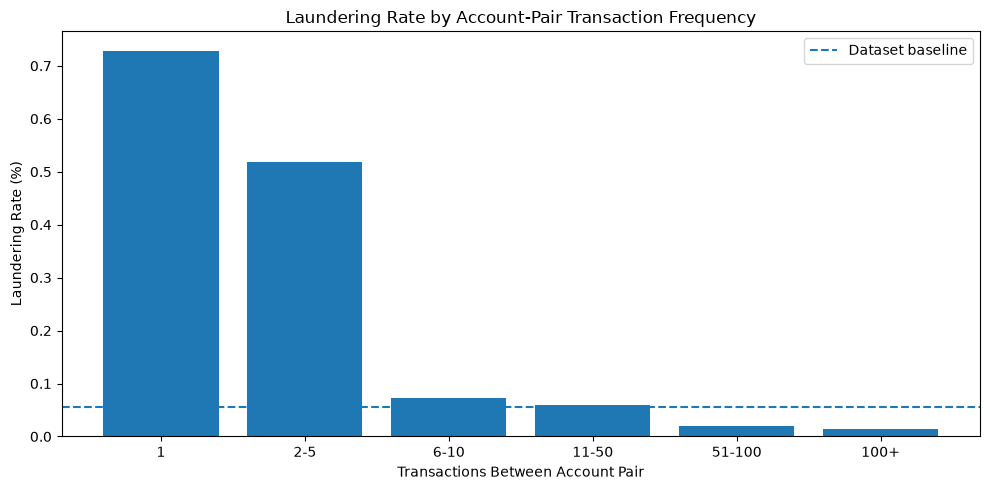

In [54]:
plt.figure(figsize=(10, 5))

plt.bar(
    pair_frequency_buckets["Pair Frequency"].cast(pl.String),
    pair_frequency_buckets["Laundering Rate"]
)

plt.axhline(
    y=baseline_rate,
    linestyle="--",
    label="Dataset baseline"
)

plt.xlabel("Transactions Between Account Pair")
plt.ylabel("Laundering Rate (%)")
plt.title("Laundering Rate by Account-Pair Transaction Frequency")

plt.legend()
plt.tight_layout()
plt.show()

### 6.3 Most active account pairs

In [55]:
top_account_pairs = (
    account_pairs
    .sort("Transactions", descending=True)
    .head(15)
)

top_account_pairs

From Bank,From Account,To Bank,To Account,Transactions,Laundering Transactions,Total Amount,Mean Amount,First Transaction,Last Transaction
i64,str,i64,str,u32,i64,f64,f64,datetime[μs],datetime[μs]
22254,"""800EC03C0""",22254,"""800EC03C0""",877,0,9.5558e8,1.0896e6,2022-08-01 00:09:00,2022-11-05 20:23:00
123456,"""80BCC3670""",123456,"""80BCC3670""",683,0,4.1681e8,610256.573016,2022-08-01 00:04:00,2022-11-05 14:53:00
25626,"""80220B470""",25626,"""80220B470""",672,0,244212.11,363.410878,2022-08-01 00:25:00,2022-11-05 12:52:00
116,"""8000E7940""",116,"""8000E7940""",672,0,23141.04,34.436071,2022-08-01 05:03:00,2022-11-05 20:42:00
210,"""845E15E80""",212,"""845E2DFF0""",641,0,2.1303e7,33233.598144,2022-08-01 01:06:00,2022-11-05 13:56:00
1208,"""80C9F1AE0""",1208,"""80C9F1AE0""",629,0,2.0967e6,3333.369793,2022-08-01 03:17:00,2022-11-05 00:16:00
11,"""80006E8A0""",11,"""80006E8A0""",628,0,2.3378e7,37226.257182,2022-08-01 09:42:00,2022-11-05 11:23:00
210711,"""84D106571""",210711,"""84D106571""",602,0,94.049644,0.156229,2022-08-01 00:17:00,2022-11-05 00:58:00
22088,"""80256C170""",22088,"""80256C170""",602,0,1.8961e8,314966.763605,2022-08-01 00:02:00,2022-11-05 00:28:00


In [56]:
top_laundering_pairs = (
    account_pairs
    .filter(
        pl.col("Laundering Transactions") > 0
    )
    .with_columns(
        (
            pl.col("Laundering Transactions") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate")
    )
    .sort("Laundering Transactions", descending=True)
    .head(15)
)

top_laundering_pairs

From Bank,From Account,To Bank,To Account,Transactions,Laundering Transactions,Total Amount,Mean Amount,First Transaction,Last Transaction,Laundering Rate
i64,str,i64,str,u32,i64,f64,f64,datetime[μs],datetime[μs],f64
4518,"""8030C8390""",952,"""8030C8340""",30,20,152399.63,5079.987667,2022-08-06 04:50:00,2022-10-31 21:13:00,66.666667
1112993,"""82A36BF50""",2104845,"""82A36BF00""",22,18,240432.42,10928.746364,2022-08-16 15:58:00,2022-11-05 15:10:00,81.818182
952,"""8030C8340""",4518,"""8030C8390""",22,17,144190.93,6554.133182,2022-08-06 11:03:00,2022-11-05 15:37:00,77.272727
2104845,"""82A36BF00""",1112993,"""82A36BF50""",20,16,240092.89,12004.6445,2022-08-11 14:25:00,2022-11-05 22:41:00,80.0
125199,"""82E7B90C0""",2125015,"""82E7B92B0""",23,14,241466.18,10498.529565,2022-08-05 19:21:00,2022-11-04 13:15:00,60.869565
2695,"""8030F9020""",22217,"""8030F8E30""",15,14,141151.78,9410.118667,2022-08-02 06:37:00,2022-10-31 14:55:00,93.333333
22217,"""8030F8E30""",2695,"""8030F9020""",15,13,122389.47,8159.298,2022-08-02 09:50:00,2022-10-20 13:34:00,86.666667
125936,"""832146A10""",1122474,"""83222DE00""",13,13,152717.76,11747.52,2022-08-07 17:00:00,2022-10-31 16:41:00,100.0
741,"""801EB6300""",257576,"""82E627EF0""",13,13,4.8126e7,3.7020e6,2022-08-02 18:00:00,2022-10-31 19:38:00,100.0


### 6.4 Reciprocal account-pair behaviour

In [57]:
reciprocal_pairs = (
    transaction_data
    .with_columns([
        pl.concat_str(
            [
                pl.col("From Bank").cast(pl.String),
                pl.lit("_"),
                pl.col("From Account")
            ]
        ).alias("From Entity"),

        pl.concat_str(
            [
                pl.col("To Bank").cast(pl.String),
                pl.lit("_"),
                pl.col("To Account")
            ]
        ).alias("To Entity")
    ])
    .with_columns([
        pl.min_horizontal(
            "From Entity",
            "To Entity"
        ).alias("Entity A"),

        pl.max_horizontal(
            "From Entity",
            "To Entity"
        ).alias("Entity B")
    ])
    .group_by([
        "Entity A",
        "Entity B"
    ])
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering"),
        pl.col("From Entity").n_unique().alias("Directions")
    ])
    .collect()
)

In [58]:
reciprocal_summary = (
    reciprocal_pairs
    .group_by("Directions")
    .agg([
        pl.len().alias("Account Relationships"),
        pl.col("Transactions").sum().alias("Transactions"),
        pl.col("Laundering").sum().alias("Laundering")
    ])
    .with_columns([
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate"),

        (
            pl.col("Laundering") /
            total_laundering * 100
        ).alias("Share of Laundering")
    ])
    .sort("Directions")
)

reciprocal_summary

Directions,Account Relationships,Transactions,Laundering,Laundering Rate,Share of Laundering
u32,u32,u32,i64,f64,f64
1,7196453,174281976,55696,0.031957,57.455281
2,488924,1778133,41242,2.319399,42.544719


### 6.5 Individual account fan-out

In [59]:
from_account_activity = (
    transaction_data
    .group_by([
        "From Bank",
        "From Account"
    ])
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering"),
        pl.col("To Account").n_unique().alias("Unique Destinations"),
        pl.col("Amount Paid").sum().alias("Total Amount")
    ])
    .collect()
)

In [60]:
destination_stats = (
    from_account_activity
    .select([
        pl.col("Unique Destinations").min().alias("Min"),
        pl.col("Unique Destinations").quantile(0.25).alias("P25"),
        pl.col("Unique Destinations").median().alias("Median"),
        pl.col("Unique Destinations").quantile(0.75).alias("P75"),
        pl.col("Unique Destinations").quantile(0.90).alias("P90"),
        pl.col("Unique Destinations").quantile(0.95).alias("P95"),
        pl.col("Unique Destinations").quantile(0.99).alias("P99"),
        pl.col("Unique Destinations").max().alias("Max")
    ])
)

destination_stats

Min,P25,Median,P75,P90,P95,P99,Max
u32,f64,f64,f64,f64,f64,f64,u32
1,1.0,2.0,4.0,7.0,8.0,39.0,56609


In [62]:
destination_buckets = (
    from_account_activity
    .with_columns(
        pl.when(pl.col("Unique Destinations") == 1)
        .then(pl.lit("1"))

        .when(pl.col("Unique Destinations") <= 5)
        .then(pl.lit("2-5"))

        .when(pl.col("Unique Destinations") <= 10)
        .then(pl.lit("6-10"))

        .when(pl.col("Unique Destinations") <= 50)
        .then(pl.lit("11-50"))

        .otherwise(pl.lit("50+"))
        .alias("Destination Count")
    )
    .group_by("Destination Count")
    .agg([
        pl.len().alias("Accounts"),
        pl.col("Transactions").sum().alias("Transactions"),
        pl.col("Laundering").sum().alias("Laundering")
    ])
    .with_columns([
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate"),

        (
            pl.col("Laundering") /
            total_laundering * 100
        ).alias("Share of Laundering")
    ])
)

destination_buckets

Destination Count,Accounts,Transactions,Laundering,Laundering Rate,Share of Laundering
str,u32,u32,i64,f64,f64
"""6-10""",257828,39893324,15214,0.038137,15.694568
"""11-50""",62731,18895191,4203,0.022244,4.335761
"""1""",711180,7366765,2019,0.027407,2.082775
"""2-5""",997963,92141958,51855,0.056277,53.492954
"""50+""",1997,17762871,23647,0.133126,24.393943


In [63]:
top_fanout_accounts = (
    from_account_activity
    .filter(pl.col("Unique Destinations") > 50)
    .with_columns(
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate")
    )
    .sort("Unique Destinations", descending=True)
    .head(15)
)

top_fanout_accounts

From Bank,From Account,Transactions,Laundering,Unique Destinations,Total Amount,Laundering Rate
i64,str,u32,i64,u32,f64,f64
70,"""10042B660""",6327667,9137,56609,1.4992e12,0.144398
70,"""10042B6A8""",3851161,5296,34788,7.8803e11,0.137517
70,"""10042B6F0""",885153,1297,7958,1.2690e12,0.146528
70,"""10042B780""",667095,965,5985,1.4015e13,0.144657
70,"""10042B858""",545835,773,4884,2.0032e11,0.141618
70,"""10042B978""",541019,765,4845,9.1331e10,0.1414
70,"""10042B8A0""",538559,771,4779,1.6559e11,0.14316
70,"""10042B810""",507060,719,4613,9.3034e10,0.141798
70,"""10042B738""",485282,628,4332,1.3090e13,0.129409


In [64]:
top_fanout_laundering = (
    from_account_activity
    .filter(pl.col("Unique Destinations") > 50)
    .with_columns(
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate")
    )
    .sort("Laundering", descending=True)
    .head(15)
)

top_fanout_laundering

From Bank,From Account,Transactions,Laundering,Unique Destinations,Total Amount,Laundering Rate
i64,str,u32,i64,u32,f64,f64
70,"""10042B660""",6327667,9137,56609,1.4992e12,0.144398
70,"""10042B6A8""",3851161,5296,34788,7.8803e11,0.137517
70,"""10042B6F0""",885153,1297,7958,1.2690e12,0.146528
70,"""10042B780""",667095,965,5985,1.4015e13,0.144657
70,"""10042B858""",545835,773,4884,2.0032e11,0.141618
70,"""10042B8A0""",538559,771,4779,1.6559e11,0.14316
70,"""10042B978""",541019,765,4845,9.1331e10,0.1414
70,"""10042B810""",507060,719,4613,9.3034e10,0.141798
70,"""10042B7C8""",449150,701,3994,1.0478e13,0.156073


In [65]:
high_fanout_by_bank = (
    from_account_activity
    .filter(pl.col("Unique Destinations") > 50)
    .group_by("From Bank")
    .agg([
        pl.len().alias("Accounts"),
        pl.col("Transactions").sum().alias("Transactions"),
        pl.col("Laundering").sum().alias("Laundering")
    ])
    .with_columns(
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate")
    )
    .sort("Laundering", descending=True)
    .head(15)
)

high_fanout_by_bank

From Bank,Accounts,Transactions,Laundering,Laundering Rate
i64,u32,u32,i64,f64
70,15,16716238,23647,0.141461
115626,1,557,0,0.0
125210,1,198,0,0.0
12,7,5402,0,0.0
235057,1,529,0,0.0
49447,1,99,0,0.0
123120,2,702,0,0.0
125079,1,98,0,0.0
276742,1,475,0,0.0
